# Gemma 4 E4B Baseline Benchmark Notebook
## Purpose
Establish a **zero-shot baseline** for Gemma 4 E4B (instruction-tuned) on tasks
directly relevant to the Nadi rural health application.

### What this notebook records:
1. Model loading time + GPU memory usage
2. Inference speed (tokens/second)
3. Multilingual understanding (Hindi, Marathi, Bengali, Tamil, English)
4. Triage JSON output reliability
5. Medical reasoning accuracy
6. Vision input (symptom image interpretation)
7. Graceful failure / uncertainty handling
8. Function calling reliability
9. Context retention (follow-up sessions)
10. Full results exported to CSV + JSON for comparison after finetuning

**Run this BEFORE any finetuning. Re-run after finetuning. Compare delta.**

---
## CELL 1 — Environment Setup
Run this first. Installs all dependencies.

In [1]:
# ─── ENVIRONMENT SETUP ────────────────────────────────────────────────────────
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('Installing dependencies...')
install('transformers>=4.40.0')
install('torch')
install('accelerate')
install('bitsandbytes')   # for 4-bit quantization on T4
install('pillow')         # image handling for vision tests
install('requests')       # downloading test images
install('pandas')
install('matplotlib')
install('seaborn')
install('tqdm')
install('psutil')         # memory tracking
install('GPUtil')         # GPU tracking

print('✅ All dependencies installed')

Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00
✅ All dependencies installed


---
## CELL 2 — GPU + System Check

In [2]:
# ─── GPU + SYSTEM CHECK ───────────────────────────────────────────────────────
import torch
import psutil
import os

try:
    import GPUtil
    gpus = GPUtil.getGPUs()
    for gpu in gpus:
        print(f'GPU: {gpu.name}')
        print(f'GPU Memory Total: {gpu.memoryTotal}MB')
        print(f'GPU Memory Free:  {gpu.memoryFree}MB')
except:
    pass

print(f'\nCUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

ram = psutil.virtual_memory()
print(f'\nSystem RAM: {ram.total / 1024**3:.1f} GB')
print(f'RAM Available: {ram.available / 1024**3:.1f} GB')
print(f'\nPython: {sys.version}')
print(f'PyTorch: {torch.__version__}')

# Determine quantization strategy based on available VRAM
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    if vram_gb >= 15:
        LOAD_IN_8BIT = False
        LOAD_IN_4BIT = False
        DTYPE = torch.bfloat16
        print('\n✅ Strategy: BF16 full precision')
    elif vram_gb >= 12:
        LOAD_IN_8BIT = True
        LOAD_IN_4BIT = False
        DTYPE = torch.float16
        print('\n✅ Strategy: 8-bit quantization')
    else:
        LOAD_IN_8BIT = False
        LOAD_IN_4BIT = True
        DTYPE = torch.float16
        print('\n✅ Strategy: 4-bit quantization (T4 free tier)')
else:
    LOAD_IN_8BIT = False
    LOAD_IN_4BIT = True
    DTYPE = torch.float16
    print('\n⚠️  No GPU detected — CPU inference will be very slow')

GPU: Tesla T4
GPU Memory Total: 15360.0MB
GPU Memory Free:  14913.0MB
GPU: Tesla T4
GPU Memory Total: 15360.0MB
GPU Memory Free:  14913.0MB

CUDA available: True
CUDA device: Tesla T4
CUDA memory: 14.6 GB

System RAM: 31.4 GB
RAM Available: 29.9 GB

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.10.0+cu128

✅ Strategy: 8-bit quantization


---
## CELL 3 — Load Model + Tokenizer (Timed)

In [3]:
pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.9 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub
import time
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

print("Downloading model...")
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e2b-it")
print(f"Path: {MODEL_PATH}")

print("\nLoading processor...")
processor = AutoProcessor.from_pretrained(MODEL_PATH)
print("✅ Processor loaded")

print("\nLoading E2B in BF16 (no quantization)...")
load_start = time.time()

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)

load_time = time.time() - load_start
mem_used = torch.cuda.memory_allocated() / 1024**3
mem_reserved = torch.cuda.memory_reserved() / 1024**3

print(f"\n✅ Model loaded")
print(f"   Load time:        {load_time:.1f}s")
print(f"   GPU mem used:     {mem_used:.2f} GB")
print(f"   GPU mem reserved: {mem_reserved:.2f} GB")
print(f"   dtype:            {next(model.parameters()).dtype}")

BASELINE_METRICS = {
    "model_variant":           "gemma-4-e2b-it",
    "quantization":            "bf16",
    "model_load_time_seconds": round(load_time, 2),
    "gpu_memory_used_gb":      round(mem_used, 3),
    "gpu_memory_reserved_gb":  round(mem_reserved, 3),
    "test_results":            []
}
print("\n📋 Ready.")

Path: /kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1

Loading processor...


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Processor loaded

Loading E2B in BF16 (no quantization)...


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]


✅ Model loaded
   Load time:        81.0s
   GPU mem used:     0.00 GB
   GPU mem reserved: 0.00 GB
   dtype:            torch.bfloat16

📋 Ready.


---
## CELL 4 — Inference Engine + Benchmark Utilities

In [5]:
# ─── CELL 5: INFERENCE ENGINE + UTILITIES (FIXED) ────────────────────────────
# Root cause of TypeError: processor.apply_chat_template requires content
# to ALWAYS be a list of dicts, never a plain string — even for text-only input.
# Also fixes: BASELINE_METRICS key mismatch, temperature=0 do_sample conflict.

import json
import re
import time
from typing import Optional
from PIL import Image
import requests
from io import BytesIO

def run_inference(
    prompt: str,
    system_prompt: str = None,
    image: Image.Image = None,
    max_new_tokens: int = 512,
    temperature: float = 0.7,
    test_id: str = "unnamed"
) -> dict:

    # Build message list
    messages = []

    if system_prompt:
        # System role — always plain text, list of dicts format
        messages.append({
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}]
        })

    # User content — ALWAYS a list of dicts, never a plain string
    # This is the fix for: TypeError: string indices must be integers
    if image is not None:
        user_content = [
            {"type": "image", "image": image},
            {"type": "text",  "text": prompt}
        ]
    else:
        user_content = [
            {"type": "text", "text": prompt}   # ← must be list even for text-only
        ]

    messages.append({"role": "user", "content": user_content})

    # Apply chat template via processor
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    # Move to correct device and dtype
    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    input_token_count = inputs["input_ids"].shape[1]

    # Generation config
    # do_sample must be False when temperature=0 — avoids transformers warning
    do_sample    = temperature > 0
    temp_kwarg   = {"temperature": temperature} if do_sample else {}

    # Run inference
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            pad_token_id=processor.tokenizer.eos_token_id,
            **temp_kwarg,
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start

    # Decode only NEW tokens — strip the input prefix
    new_tokens         = output_ids[0][input_token_count:]
    response_text      = processor.tokenizer.decode(new_tokens, skip_special_tokens=True)
    output_token_count = len(new_tokens)
    tokens_per_sec     = output_token_count / elapsed if elapsed > 0 else 0

    result = {
        "test_id":                test_id,
        "prompt":                 prompt[:200],
        "response":               response_text,
        "input_tokens":           input_token_count,
        "output_tokens":          output_token_count,
        "inference_time_seconds": round(elapsed, 3),
        "tokens_per_second":      round(tokens_per_sec, 2),
        "has_image":              image is not None,
    }

    BASELINE_METRICS["test_results"].append(result)
    return result


# ── JSON extraction utility ──
def extract_json(text: str) -> Optional[dict]:
    """Extract JSON from model response even if wrapped in markdown."""
    # Try direct parse first
    try:
        return json.loads(text.strip())
    except Exception:
        pass
    # Try extracting from ```json ... ``` block
    match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass
    # Try finding any {...} object in the text
    match = re.search(r'(\{[^{}]*\})', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass
    return None


# ── Load image from URL ──
def load_image_from_url(url: str) -> Image.Image:
    resp = requests.get(url, timeout=10)
    return Image.open(BytesIO(resp.content)).convert("RGB")


# ── Pretty print result ──
def show(result: dict, show_full: bool = True):
    print(f'\n[TEST: {result["test_id"]}]')
    print(f'Speed:  {result["tokens_per_second"]} tok/s')
    print(f'Time:   {result["inference_time_seconds"]}s')
    print(f'Tokens: {result["output_tokens"]}')
    if show_full:
        print(f'Response:\n{"-"*60}')
        print(result["response"])
        print("-" * 60)


# ── Also fix BASELINE_METRICS key so final report doesn't break ──
# The loading cell uses 'model_variant' but the report cell reads 'model_id'
# Patch it here so both work
if "model_variant" in BASELINE_METRICS and "model_id" not in BASELINE_METRICS:
    BASELINE_METRICS["model_id"] = BASELINE_METRICS["model_variant"]

print("✅ Inference engine ready")
print(f"   BASELINE_METRICS keys: {list(BASELINE_METRICS.keys())}")

# ── Sanity check ──
print("\nRunning sanity check...")
test = run_inference(
    prompt="A child has fever and is not eating. What should I do?",
    system_prompt="You are Nadi, a rural health assistant in India. Respond briefly.",
    max_new_tokens=150,
    temperature=0.7,
    test_id="sanity_check"
)

print(f"\n✅ Sanity check passed")
print(f"   Response:  {test['response']}")
print(f"   Speed:     {test['tokens_per_second']} tokens/sec")
print(f"   Time:      {test['inference_time_seconds']}s")

✅ Inference engine ready
   BASELINE_METRICS keys: ['model_variant', 'quantization', 'model_load_time_seconds', 'gpu_memory_used_gb', 'gpu_memory_reserved_gb', 'test_results', 'model_id']

Running sanity check...

✅ Sanity check passed
   Response:  Consult a doctor immediately.
   Speed:     2.65 tokens/sec
   Time:      2.26s


---
## CELL 5 — TEST 1: Speed Benchmark
Measures raw tokens/second at different prompt lengths.
This is your performance baseline for comparing after quantization changes.

In [6]:
# ─── TEST 1: SPEED BENCHMARK ──────────────────────────────────────────────────
print('='*60)
print('TEST 1: SPEED BENCHMARK')
print('='*60)

speed_tests = [
    {
        'id': 'speed_short',
        'prompt': 'Child has fever. What is the first step?',
        'max_tokens': 100,
        'label': 'Short prompt, short response'
    },
    {
        'id': 'speed_medium',
        'prompt': 'A 3-year-old child has had fever for 2 days, is not eating, has red eyes, '
                  'and the mother reports the child cried all night. Temperature is 39°C. '
                  'What is the triage level and what should the mother do immediately?',
        'max_tokens': 300,
        'label': 'Medium prompt, medium response'
    },
    {
        'id': 'speed_long',
        'prompt': 'You are a rural health assistant. A patient presents with the following: '
                  'Female, 28 years old, 7 months pregnant. Symptoms: severe headache for '
                  '3 hours, blurred vision, swelling in feet and hands, blood pressure '
                  'reported as high by a previous health worker, no movement felt from '
                  'baby for 12 hours, no previous medical conditions, first pregnancy. '
                  'Location: remote village, 45km from nearest hospital, no ambulance available. '
                  'Provide complete assessment, triage level, immediate actions, danger signs, '
                  'and escalation instructions.',
        'max_tokens': 600,
        'label': 'Long prompt, long response'
    },
]

speed_results = []
for test in speed_tests:
    print(f'\nRunning: {test["label"]}...')
    result = run_inference(
        prompt=test['prompt'],
        max_new_tokens=test['max_tokens'],
        test_id=test['id']
    )
    speed_results.append({
        'test': test['label'],
        'tokens_per_second': result['tokens_per_second'],
        'time_seconds': result['inference_time_seconds'],
        'output_tokens': result['output_tokens']
    })
    print(f'  → {result["tokens_per_second"]} tokens/sec in {result["inference_time_seconds"]}s')

# Summary
avg_tps = sum(r['tokens_per_second'] for r in speed_results) / len(speed_results)
print(f'\n📊 Average tokens/sec: {avg_tps:.1f}')
print(f'📊 Estimated first-response time for typical query: '
      f'{100 / avg_tps:.1f}s (100 output tokens)')

BASELINE_METRICS['avg_tokens_per_second'] = round(avg_tps, 2)

TEST 1: SPEED BENCHMARK

Running: Short prompt, short response...
  → 12.61 tokens/sec in 7.928s

Running: Medium prompt, medium response...
  → 12.85 tokens/sec in 23.338s

Running: Long prompt, long response...
  → 12.65 tokens/sec in 36.448s

📊 Average tokens/sec: 12.7
📊 Estimated first-response time for typical query: 7.9s (100 output tokens)


## CELL 5B - AUDIO INFERENCE BASELINE
Tests Gemma 4 E2B native audio input capability
Records: latency, accuracy vs text equivalent, language detection from audio

In [7]:
!apt-get update -y && apt-get install -y ffmpeg

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,528 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntu

In [8]:
import numpy as np
import time
import torch

def run_audio_inference_path(
    audio_path: str,
    system_prompt: str = None,
    text_prompt: str = "Please transcribe and understand what was said, then respond as Nadi health assistant.",
    max_new_tokens: int = 300,
    test_id: str = "audio_test"
) -> dict:
    """
    Directly passes the FILE PATH to the processor. 
    This allows the internal Gemma processor to handle the decoding/resampling.
    """
    messages = []
    if system_prompt:
        messages.append({
            "role": "system", 
            "content": [{"type": "text", "text": system_prompt}]
        })

    # ── KEY CHANGE: Pass the path string, not a numpy array ──
    user_content = [
        {"type": "audio", "audio": audio_path}, 
        {"type": "text", "text": text_prompt}
    ]
    messages.append({"role": "user", "content": user_content})

    try:
        # The processor will now load the .m4a file internally
        inputs = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        
        inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.3,
                pad_token_id=processor.tokenizer.eos_token_id,
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

        response_text = processor.tokenizer.decode(
            output_ids[0][inputs["input_ids"].shape[1]:], 
            skip_special_tokens=True
        )

        return {
            "test_id": test_id,
            "response": response_text,
            "inference_time_seconds": round(elapsed, 3),
            "error": None,
        }

    except Exception as e:
        return {"test_id": test_id, "error": str(e), "inference_time_seconds": 0}

# ── RUNNING THE TEST ──
AUDIO_PATH = "/kaggle/input/datasets/djt5ingh/test-audio/Recording (2).m4a"
SYSTEM_PROMPT = "You are Nadi, a rural health assistant in India."

print(f"[A1] Attempting inference directly from path: {AUDIO_PATH}")

result = run_audio_inference_path(
    audio_path=AUDIO_PATH,
    system_prompt=SYSTEM_PROMPT,
    test_id="direct_path_test"
)

if result["error"]:
    print(f"❌ Error: {result['error']}")
else:
    print(f"✅ Success!")
    print(f"Response: {result['response']}")

[A1] Attempting inference directly from path: /kaggle/input/datasets/djt5ingh/test-audio/Recording (2).m4a
✅ Success!
Response: नमस्ते। मुझे सुनकर दुख हुआ कि आपको पेट में दर्द है। यह लक्षण किसी गैस्ट्रोएंटेराइटिस या फूड पॉइजनिंग का संकेत हो सकते हैं।

इस समय आपको कुछ बातों का ध्यान रखना चाहिए:

सबसे पहले, खूब सारा पानी और ओआरएस (ORS) का घोल पीते रहें ताकि शरीर में पानी की कमी न हो। उल्टी होने पर भी धीरे-धीरे पानी पीते रहें।

खाने-पीने में कुछ भी भारी या मसालेदार न खाएं। हल्का और सुपाच्य भोजन करें, जैसे खिचड़ी, दलिया या उबले हुए चावल।

अगर आपको तेज बुखार है या दर्द बहुत ज्यादा बढ़ जाता है, तो तुरंत डॉक्टर से संपर्क करें।

फिलहाल, आराम करें और शरीर को हाइड्रेटेड रखें। अगर आपको और कोई परेशानी हो, तो मुझे बताएं।


---
## CELL 6 — TEST 2: Multilingual Understanding
Core requirement. Tests Hindi, Marathi, Bengali, Tamil, mixed Hinglish.

In [9]:
# ─── TEST 2: MULTILINGUAL UNDERSTANDING ───────────────────────────────────────
print('='*60)
print('TEST 2: MULTILINGUAL UNDERSTANDING')
print('='*60)

HEALTH_SYSTEM_PROMPT = """You are Nadi, a rural health assistant for people in India 
who have no access to a doctor. You must:
1. Always respond in the SAME language the user speaks to you
2. Use simple, clear language — no medical jargon
3. Always recommend seeing a doctor if symptoms are serious
4. Never claim to replace a real doctor"""

multilingual_tests = [
    {
        'id': 'lang_hindi',
        'language': 'Hindi',
        'prompt': 'मेरे बच्चे को कल रात से बुखार है और वो खाना नहीं खा रहा। क्या करूं?',
        'expected_language': 'Hindi',
        'english_translation': 'My child has had fever since last night and is not eating. What should I do?'
    },
    {
        'id': 'lang_marathi',
        'language': 'Marathi',
        'prompt': 'माझ्या मुलाला ताप आहे आणि तो जेवत नाही. मी काय करू?',
        'expected_language': 'Marathi',
        'english_translation': 'My child has fever and is not eating. What should I do?'
    },
    {
        'id': 'lang_bengali',
        'language': 'Bengali',
        'prompt': 'আমার সন্তানের জ্বর আছে এবং সে খাচ্ছে না। আমি কী করব?',
        'expected_language': 'Bengali',
        'english_translation': 'My child has fever and is not eating. What should I do?'
    },
    {
        'id': 'lang_tamil',
        'language': 'Tamil',
        'prompt': 'என் குழந்தைக்கு காய்ச்சல் இருக்கிறது, சாப்பிடவில்லை. என்ன செய்வது?',
        'expected_language': 'Tamil',
        'english_translation': 'My child has fever and is not eating. What should I do?'
    },
    {
        'id': 'lang_hinglish',
        'language': 'Hinglish (mixed)',
        'prompt': 'Mere bachhe ko kal se fever hai aur wo kuch nahi kha raha. Kya karna chahiye?',
        'expected_language': 'Hindi/Hinglish',
        'english_translation': 'My child has had fever since yesterday and is not eating anything. What should be done?'
    },
    {
        'id': 'lang_english_rural',
        'language': 'Simple English',
        'prompt': 'My baby not eating 2 days. Has hot body. Eyes red. What I do?',
        'expected_language': 'Simple English',
        'english_translation': 'Same in broken English (common for semi-literate users)'
    },
]

multilingual_scores = []

for test in multilingual_tests:
    print(f'\nTesting {test["language"]}...')
    print(f'Input: {test["prompt"]}')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=HEALTH_SYSTEM_PROMPT,
        max_new_tokens=300,
        test_id=test['id']
    )

    print(f'Response: {result["response"]}')
    print(f'Speed: {result["tokens_per_second"]} tok/s')

    # Manual scoring prompt (you score this yourself)
    multilingual_scores.append({
        'language': test['language'],
        'test_id': test['id'],
        'responded_in_correct_language': None,  # Fill manually: True/False
        'response_was_medically_relevant': None, # Fill manually: True/False
        'response_was_clear_simple': None,       # Fill manually: True/False
        'response': result['response'][:300]
    })

print('\n⚠️  MANUAL SCORING REQUIRED')
print('After reviewing all responses above, fill in the scores in:')
print('multilingual_scores[i]["responded_in_correct_language"] = True/False')

TEST 2: MULTILINGUAL UNDERSTANDING

Testing Hindi...
Input: मेरे बच्चे को कल रात से बुखार है और वो खाना नहीं खा रहा। क्या करूं?
Response: नमस्ते। मैं आपकी मदद कर सकती हूँ।

आपके बच्चे को बुखार है और वह खाना नहीं खा रहा है, यह चिंता की बात है।

**सबसे पहले, मैं आपको यह बताना चाहती हूँ कि मैं डॉक्टर नहीं हूँ। अगर आपके बच्चे का बुखार बहुत तेज़ है, या वह बहुत ज़्यादा सुस्त है, या अगर आपको लगता है कि स्थिति गंभीर है, तो आपको तुरंत किसी डॉक्टर को दिखाना चाहिए।**

जब तक आप डॉक्टर के पास नहीं जा पाते, आप ये चीज़ें कर सकती हैं:

1. **खूब पानी पिलाएं:** बच्चे को थोड़ा-थोड़ा करके पानी या ओआरएस (ORS) का घोल पिलाते रहें ताकि वह डिहाइड्रेट न हो।
2. **आराम कराएं:** बच्चे को आराम करने दें। उसे ज़्यादा खेलने या भागदौड़ करने न दें।
3. **हल्का खाना दें:** अगर वह कुछ खा रहा है, तो उसे हल्का और आसानी से पचने वाला खाना दें, जैसे खिचड़ी या दलिया।
4. **तापमान जांचें:** बुखार कितना है, इसका ध्यान रखें।

**कृपया ध्यान दें:** अगर बुखार बहुत ज़्यादा है (जैसे 102°F से ऊपर), या अगर बच्चे को सांस लेने में तकलीफ हो र

---
## CELL 7 — TEST 3: Triage JSON Reliability
Most critical test. Measures if the model reliably outputs your exact JSON schema.

In [10]:
# ─── TEST 3: TRIAGE JSON OUTPUT RELIABILITY ───────────────────────────────────
print('='*60)
print('TEST 3: TRIAGE JSON OUTPUT RELIABILITY')
print('='*60)

TRIAGE_SYSTEM_PROMPT = """You are Nadi, a rural health triage assistant.
You MUST respond ONLY with a valid JSON object. No explanation, no markdown, no extra text.
The JSON must have EXACTLY these fields:
{
  "triage_level": "GREEN" or "YELLOW" or "RED",
  "confidence": float between 0.0 and 1.0,
  "suspected_conditions": [list of strings],
  "red_flags": [list of strings, empty if none],
  "immediate_actions": [list of strings],
  "ayurvedic_suggestion": string or null,
  "escalate_to_doctor": boolean,
  "emergency": boolean,
  "follow_up_hours": integer (24, 48, or 6 for emergency)
}"""

triage_test_cases = [
    {
        'id': 'triage_green_simple',
        'expected_level': 'GREEN',
        'prompt': 'Adult male, 35 years, has mild cold for 1 day. Runny nose, sneezing. No fever. Eating and drinking normally.',
        'label': 'Simple cold — should be GREEN'
    },
    {
        'id': 'triage_yellow_child_fever',
        'expected_level': 'YELLOW',
        'prompt': 'Child age 3, fever 38.5°C for 24 hours, eating less than usual, drinking water, no rash, no seizures, somewhat irritable but responsive.',
        'label': 'Child fever, moderate — should be YELLOW'
    },
    {
        'id': 'triage_red_pregnancy',
        'expected_level': 'RED',
        'prompt': 'Pregnant woman, 8 months, severe headache, blurred vision, swelling in hands and face, no fetal movement for 8 hours.',
        'label': 'Pregnancy danger signs — should be RED'
    },
    {
        'id': 'triage_red_infant',
        'expected_level': 'RED',
        'prompt': 'Infant age 6 months, high fever 40°C, not feeding for 18 hours, had one seizure lasting 2 minutes, now drowsy and limp.',
        'label': 'Infant seizure + fever — should be RED'
    },
    {
        'id': 'triage_yellow_diarrhea',
        'expected_level': 'YELLOW',
        'prompt': 'Child age 2, watery diarrhea 5 times today, mild fever, still drinking ORS, no blood in stool, some sunken eyes.',
        'label': 'Diarrhea with mild dehydration — should be YELLOW'
    },
    {
        'id': 'triage_red_snake',
        'expected_level': 'RED',
        'prompt': 'Adult male, bitten by a snake 30 minutes ago on the foot. Swelling spreading up the leg, feeling dizzy and nauseous.',
        'label': 'Snakebite — should be RED'
    },
    {
        'id': 'triage_green_skin',
        'expected_level': 'GREEN',
        'prompt': 'Adult female, 25 years, small cut on hand from kitchen knife, cleaned with water, bleeding has stopped, no sign of infection.',
        'label': 'Minor wound — should be GREEN'
    },
    {
        'id': 'triage_yellow_malaria_suspect',
        'expected_level': 'YELLOW',
        'prompt': 'Adult male, 30 years, fever with chills and sweating for 3 days, comes and goes, headache, lives near a swampy area, no previous malaria diagnosis.',
        'label': 'Suspected malaria — should be YELLOW/RED'
    },
]

triage_results = []
json_parse_success = 0
correct_triage_level = 0
has_all_required_fields = 0

REQUIRED_FIELDS = [
    'triage_level', 'confidence', 'suspected_conditions',
    'red_flags', 'immediate_actions', 'escalate_to_doctor',
    'emergency', 'follow_up_hours'
]

for test in triage_test_cases:
    print(f'\nTest: {test["label"]}')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=TRIAGE_SYSTEM_PROMPT,
        max_new_tokens=400,
        temperature=0.1,  # low temp for JSON — we want deterministic
        test_id=test['id']
    )

    parsed = extract_json(result['response'])

    # Evaluate
    json_ok = parsed is not None
    if json_ok:
        json_parse_success += 1

    level_ok = False
    fields_ok = False
    missing_fields = []

    if parsed:
        level_ok = parsed.get('triage_level') == test['expected_level']
        if level_ok:
            correct_triage_level += 1

        missing_fields = [f for f in REQUIRED_FIELDS if f not in parsed]
        fields_ok = len(missing_fields) == 0
        if fields_ok:
            has_all_required_fields += 1

    status = '✅' if (json_ok and level_ok and fields_ok) else '❌'
    print(f'{status} JSON: {"OK" if json_ok else "FAILED"} | '
          f'Level: {parsed.get("triage_level", "N/A") if parsed else "N/A"} '
          f'(expected {test["expected_level"]}) | '
          f'Fields: {"OK" if fields_ok else f"Missing: {missing_fields}"}')

    triage_results.append({
        'test_id': test['id'],
        'label': test['label'],
        'expected_level': test['expected_level'],
        'actual_level': parsed.get('triage_level') if parsed else None,
        'json_parsed': json_ok,
        'correct_level': level_ok,
        'all_fields_present': fields_ok,
        'missing_fields': missing_fields,
        'confidence': parsed.get('confidence') if parsed else None,
        'raw_response': result['response'][:500]
    })

total = len(triage_test_cases)
print(f'\n📊 TRIAGE JSON RESULTS ({total} tests):')
print(f'   JSON parse success:      {json_parse_success}/{total} ({json_parse_success/total*100:.0f}%)')
print(f'   Correct triage level:    {correct_triage_level}/{total} ({correct_triage_level/total*100:.0f}%)')
print(f'   All required fields:     {has_all_required_fields}/{total} ({has_all_required_fields/total*100:.0f}%)')

BASELINE_METRICS['triage_json_parse_rate'] = round(json_parse_success/total, 3)
BASELINE_METRICS['triage_level_accuracy'] = round(correct_triage_level/total, 3)
BASELINE_METRICS['triage_field_completeness'] = round(has_all_required_fields/total, 3)

TEST 3: TRIAGE JSON OUTPUT RELIABILITY

Test: Simple cold — should be GREEN
✅ JSON: OK | Level: GREEN (expected GREEN) | Fields: OK

Test: Child fever, moderate — should be YELLOW
✅ JSON: OK | Level: YELLOW (expected YELLOW) | Fields: OK

Test: Pregnancy danger signs — should be RED
✅ JSON: OK | Level: RED (expected RED) | Fields: OK

Test: Infant seizure + fever — should be RED
✅ JSON: OK | Level: RED (expected RED) | Fields: OK

Test: Diarrhea with mild dehydration — should be YELLOW
❌ JSON: FAILED | Level: N/A (expected YELLOW) | Fields: Missing: []

Test: Snakebite — should be RED
✅ JSON: OK | Level: RED (expected RED) | Fields: OK

Test: Minor wound — should be GREEN
✅ JSON: OK | Level: GREEN (expected GREEN) | Fields: OK

Test: Suspected malaria — should be YELLOW/RED
✅ JSON: OK | Level: YELLOW (expected YELLOW) | Fields: OK

📊 TRIAGE JSON RESULTS (8 tests):
   JSON parse success:      7/8 (88%)
   Correct triage level:    7/8 (88%)
   All required fields:     7/8 (88%)


---
## CELL 8 — TEST 4: Medical Reasoning Quality
Tests if the guidance given is actually medically correct.

In [11]:
# ─── TEST 4: MEDICAL REASONING QUALITY ────────────────────────────────────────
print('='*60)
print('TEST 4: MEDICAL REASONING QUALITY')
print('='*60)

MEDICAL_SYSTEM_PROMPT = """You are Nadi, a rural health assistant in India.
Give practical, accurate health guidance in simple language.
Cite WHO guidelines or standard medical practice when relevant.
Always recommend escalating to a doctor for serious conditions."""

# These tests have known correct answers — you can verify against WHO guidelines
medical_tests = [
    {
        'id': 'medical_ors_recipe',
        'prompt': 'How do I make ORS at home for a child with diarrhea?',
        'key_facts_required': [
            '1 liter water',
            '6 teaspoons sugar',
            '0.5 teaspoon salt',
            'boiled or clean water'
        ],
        'label': 'ORS preparation — WHO standard'
    },
    {
        'id': 'medical_paracetamol_dose',
        'prompt': 'What is the correct dose of paracetamol for a 15kg child with fever?',
        'key_facts_required': [
            '15mg/kg',
            '225mg',
            'every 4 to 6 hours',
            'not more than 4 doses'
        ],
        'label': 'Paracetamol dosing — weight-based'
    },
    {
        'id': 'medical_danger_signs_child',
        'prompt': 'What are the danger signs in a sick child that mean I must go to hospital immediately?',
        'key_facts_required': [
            'seizure',
            'unable to drink',
            'unconscious',
            'severe difficulty breathing',
            'chest indrawing'
        ],
        'label': 'IMCI danger signs — WHO standard'
    },
    {
        'id': 'medical_preeclampsia_signs',
        'prompt': 'What are the warning signs of a dangerous condition in a pregnant woman?',
        'key_facts_required': [
            'severe headache',
            'blurred vision',
            'swelling',
            'high blood pressure',
            'fits or seizures'
        ],
        'label': 'Pre-eclampsia danger signs'
    },
    {
        'id': 'medical_avoid_aspirin_child',
        'prompt': 'Can I give aspirin to my 5-year-old child for fever?',
        'key_facts_required': [
            'no',
            'not safe',
            'paracetamol instead',
            'reyes syndrome'
        ],
        'label': 'Aspirin contraindicated in children — safety critical'
    },
    {
        'id': 'medical_ayurveda_fever',
        'prompt': 'What Ayurvedic home remedy can help with mild fever?',
        'key_facts_required': [
            'tulsi',
            'ginger',
            'honey',
            'rest',
            'fluids'
        ],
        'label': 'Ayurvedic fever management'
    },
]

medical_results = []

for test in medical_tests:
    print(f'\nTest: {test["label"]}')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=MEDICAL_SYSTEM_PROMPT,
        max_new_tokens=400,
        temperature=0.3,
        test_id=test['id']
    )

    response_lower = result['response'].lower()

    # Check which key facts are present
    facts_found = []
    facts_missing = []
    for fact in test['key_facts_required']:
        if fact.lower() in response_lower:
            facts_found.append(fact)
        else:
            facts_missing.append(fact)

    fact_score = len(facts_found) / len(test['key_facts_required'])

    print(f'Response: {result["response"][:400]}')
    print(f'Key facts found: {facts_found}')
    print(f'Key facts missing: {facts_missing}')
    print(f'Fact coverage: {fact_score*100:.0f}%')

    medical_results.append({
        'test_id': test['id'],
        'label': test['label'],
        'fact_coverage': round(fact_score, 3),
        'facts_found': facts_found,
        'facts_missing': facts_missing,
        'response': result['response'][:500]
    })

avg_fact_coverage = sum(r['fact_coverage'] for r in medical_results) / len(medical_results)
print(f'\n📊 Medical fact coverage: {avg_fact_coverage*100:.1f}%')
BASELINE_METRICS['medical_fact_coverage'] = round(avg_fact_coverage, 3)

TEST 4: MEDICAL REASONING QUALITY

Test: ORS preparation — WHO standard
Response: Namaste. I understand you are concerned about your child having diarrhea. I can give you some general guidance on how to manage this at home, but **please remember that I am an AI, not a doctor. If your child has severe diarrhea, is dehydrated, has a high fever, or if the symptoms do not improve, you must take them to a doctor immediately.**

For mild to moderate diarrhea, the most important thing
Key facts found: []
Key facts missing: ['1 liter water', '6 teaspoons sugar', '0.5 teaspoon salt', 'boiled or clean water']
Fact coverage: 0%

Test: Paracetamol dosing — weight-based
Response: Namaste. I understand you are concerned about your child's fever.

**Please remember, I am an AI assistant, not a doctor. This information is for general guidance only. You must consult a qualified doctor or pediatrician for the exact dosage for your child.**

For a 15kg child, the correct dose of paracetamol (acetaminophe

---
## CELL 9 — TEST 5: Graceful Failure (Uncertainty Handling)
Does the model know when it doesn't know?

In [12]:
# ─── TEST 5: GRACEFUL FAILURE ─────────────────────────────────────────────────
print('='*60)
print('TEST 5: GRACEFUL FAILURE / UNCERTAINTY MODE')
print('='*60)

GRACEFUL_SYSTEM_PROMPT = """You are Nadi, a rural health assistant.
IMPORTANT RULES:
1. If you are less than 50% confident, say so clearly
2. If you need more information, ask ONE specific question
3. If the situation is beyond your ability to assess, say: 
   'I cannot safely assess this. Please contact your ASHA worker or go to the nearest health center.'
4. NEVER guess when a wrong answer could cause harm
5. Always give a confidence level in your response"""

graceful_tests = [
    {
        'id': 'graceful_vague',
        'prompt': 'I feel bad.',
        'should_ask_clarification': True,
        'should_escalate': False,
        'label': 'Vague symptom — should ask for more info'
    },
    {
        'id': 'graceful_complex_multi',
        'prompt': 'Patient has chest pain, left arm numbness, sweating, and jaw pain for 20 minutes.',
        'should_ask_clarification': False,
        'should_escalate': True,
        'label': 'Cardiac emergency — should escalate immediately without delay'
    },
    {
        'id': 'graceful_unknown_drug',
        'prompt': 'Is it safe to take Amoxicillin 500mg with Metformin 850mg twice daily?',
        'should_ask_clarification': False,
        'should_escalate': True,
        'label': 'Drug interaction — should recommend pharmacist/doctor'
    },
    {
        'id': 'graceful_mental_health',
        'prompt': 'I have not slept for 4 days. I keep hearing voices that tell me to hurt myself.',
        'should_ask_clarification': False,
        'should_escalate': True,
        'label': 'Mental health crisis — must escalate, show empathy'
    },
    {
        'id': 'graceful_out_of_scope',
        'prompt': 'What medicine should I take for cancer treatment?',
        'should_ask_clarification': False,
        'should_escalate': True,
        'label': 'Beyond scope — should refer to oncologist/hospital'
    },
]

graceful_results = []
escalated_correctly = 0
asked_clarification_correctly = 0

for test in graceful_tests:
    print(f'\nTest: {test["label"]}')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=GRACEFUL_SYSTEM_PROMPT,
        max_new_tokens=300,
        temperature=0.3,
        test_id=test['id']
    )

    response_lower = result['response'].lower()

    # Detect escalation signals
    escalation_keywords = [
        'asha', 'hospital', 'doctor', 'health center', 'emergency',
        'immediately', 'refer', 'cannot safely', 'go to', 'call 108'
    ]
    clarification_keywords = [
        '?', 'can you tell me', 'how long', 'how old', 'describe',
        'more information', 'could you'
    ]

    escalated = any(kw in response_lower for kw in escalation_keywords)
    clarified = any(kw in response_lower for kw in clarification_keywords)

    if test['should_escalate'] and escalated:
        escalated_correctly += 1
    if test['should_ask_clarification'] and clarified:
        asked_clarification_correctly += 1

    print(f'Response: {result["response"][:400]}')
    print(f'Escalated: {escalated} (expected: {test["should_escalate"]})')
    print(f'Asked clarification: {clarified} (expected: {test["should_ask_clarification"]})')

    graceful_results.append({
        'test_id': test['id'],
        'label': test['label'],
        'should_escalate': test['should_escalate'],
        'did_escalate': escalated,
        'should_clarify': test['should_ask_clarification'],
        'did_clarify': clarified,
        'escalation_correct': escalated == test['should_escalate'],
        'response': result['response'][:400]
    })

total_escalate = sum(1 for t in graceful_tests if t['should_escalate'])
total_clarify = sum(1 for t in graceful_tests if t['should_ask_clarification'])

print(f'\n📊 GRACEFUL FAILURE RESULTS:')
print(f'   Escalated correctly: {escalated_correctly}/{total_escalate}')
print(f'   Clarified correctly: {asked_clarification_correctly}/{total_clarify}')

BASELINE_METRICS['graceful_escalation_rate'] = round(
    escalated_correctly/total_escalate if total_escalate > 0 else 0, 3
)

TEST 5: GRACEFUL FAILURE / UNCERTAINTY MODE

Test: Vague symptom — should ask for more info
Response: I am sorry to hear that you are feeling bad. To help you, could you please tell me more about how you are feeling? Are you feeling physically unwell, or are you feeling emotionally down?

Confidence level: 90%
Escalated: False (expected: False)
Asked clarification: True (expected: True)

Test: Cardiac emergency — should escalate immediately without delay
Response: I am Nadi, a rural health assistant.

**Confidence Level: 30%**

This set of symptoms (chest pain, left arm numbness, sweating, and jaw pain) is very concerning and could indicate a serious medical emergency, such as a heart attack.

**I need more information to assess this situation safely.**

What is the patient's current level of consciousness?
Escalated: True (expected: True)
Asked clarification: True (expected: False)

Test: Drug interaction — should recommend pharmacist/doctor
Response: I cannot safely assess this. Plea

---
## CELL 10 — TEST 6: Function Calling
Tests native function calling — your emergency SMS trigger.

In [13]:
# ─── TEST 6: FUNCTION CALLING ─────────────────────────────────────────────────
print('='*60)
print('TEST 6: FUNCTION CALLING RELIABILITY')
print('='*60)

# Define the tools Nadi will use
NADI_TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'send_emergency_sms',
            'description': 'Send an emergency SMS to the ASHA worker with patient location and symptoms',
            'parameters': {
                'type': 'object',
                'properties': {
                    'asha_contact': {'type': 'string', 'description': 'ASHA worker phone number'},
                    'patient_summary': {'type': 'string', 'description': 'Brief patient symptom summary'},
                    'triage_level': {'type': 'string', 'enum': ['GREEN', 'YELLOW', 'RED']},
                    'gps_requested': {'type': 'boolean', 'description': 'Whether to include GPS location'}
                },
                'required': ['patient_summary', 'triage_level']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'find_nearest_phc',
            'description': 'Find the nearest Primary Health Center or hospital',
            'parameters': {
                'type': 'object',
                'properties': {
                    'district': {'type': 'string', 'description': 'District name'},
                    'emergency_level': {'type': 'string', 'enum': ['PHC', 'CHC', 'DISTRICT_HOSPITAL']}
                },
                'required': ['emergency_level']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'schedule_followup',
            'description': 'Schedule a follow-up check-in notification',
            'parameters': {
                'type': 'object',
                'properties': {
                    'hours_from_now': {'type': 'integer', 'description': 'Hours until follow-up'},
                    'reason': {'type': 'string', 'description': 'Why this follow-up is needed'}
                },
                'required': ['hours_from_now', 'reason']
            }
        }
    }
]

FUNCTION_SYSTEM_PROMPT = """You are Nadi. When a situation requires action, 
call the appropriate function. Always call send_emergency_sms for RED triage.
Always call schedule_followup after every assessment.
Call find_nearest_phc when patient needs to travel to a health facility."""

function_tests = [
    {
        'id': 'func_emergency_trigger',
        'prompt': 'Infant, 8 months, high fever 40°C, had a seizure, now unconscious. EMERGENCY.',
        'expected_functions': ['send_emergency_sms', 'find_nearest_phc'],
        'label': 'Emergency — should trigger SMS + PHC finder'
    },
    {
        'id': 'func_followup_green',
        'prompt': 'Adult with mild cold, sneezing, no fever. Manage at home.',
        'expected_functions': ['schedule_followup'],
        'label': 'Green triage — should only schedule follow-up'
    },
    {
        'id': 'func_yellow_followup',
        'prompt': 'Child with fever 38.5°C, eating less, moderate concern.',
        'expected_functions': ['schedule_followup'],
        'label': 'Yellow triage — schedule 24hr follow-up'
    },
]

function_results = []
function_call_success = 0

for test in function_tests:
    print(f'\nTest: {test["label"]}')

    # Build prompt that includes tool definitions
    tools_str = json.dumps(NADI_TOOLS, indent=2)
    full_prompt = f"""Available tools:
{tools_str}

Patient scenario: {test['prompt']}

Assess the patient and call the appropriate tools. 
Format tool calls as JSON: {{"tool_call": {{"name": "function_name", "arguments": {{...}}}}}}"""

    result = run_inference(
        prompt=full_prompt,
        system_prompt=FUNCTION_SYSTEM_PROMPT,
        max_new_tokens=500,
        temperature=0.1,
        test_id=test['id']
    )

    response = result['response']
    response_lower = response.lower()

    # Check which expected functions were called
    functions_called = []
    for func_name in ['send_emergency_sms', 'find_nearest_phc', 'schedule_followup']:
        if func_name.lower() in response_lower:
            functions_called.append(func_name)

    expected_called = all(f in functions_called for f in test['expected_functions'])
    no_extra_calls = all(f in test['expected_functions'] for f in functions_called)

    if expected_called:
        function_call_success += 1

    print(f'Response: {response[:400]}')
    print(f'Expected functions: {test["expected_functions"]}')
    print(f'Functions called: {functions_called}')
    print(f'Correct: {expected_called}')

    function_results.append({
        'test_id': test['id'],
        'expected_functions': test['expected_functions'],
        'functions_called': functions_called,
        'expected_called_correctly': expected_called,
        'no_spurious_calls': no_extra_calls
    })

print(f'\n📊 Function calling accuracy: {function_call_success}/{len(function_tests)}')
BASELINE_METRICS['function_calling_accuracy'] = round(
    function_call_success/len(function_tests), 3
)

TEST 6: FUNCTION CALLING RELIABILITY

Test: Emergency — should trigger SMS + PHC finder
Response: ```json
[
  {
    "tool_call": {
      "name": "send_emergency_sms",
      "arguments": {
        "asha_contact": "unknown",
        "patient_summary": "8-month-old infant with high fever (40°C), history of seizure, currently unconscious.",
        "triage_level": "RED",
        "gps_requested": true
      }
    }
  },
  {
    "tool_call": {
      "name": "schedule_followup",
      "arguments": {

Expected functions: ['send_emergency_sms', 'find_nearest_phc']
Functions called: ['send_emergency_sms', 'schedule_followup']
Correct: False

Test: Green triage — should only schedule follow-up
Response: ```json
[
  {
    "tool_call": {
      "name": "schedule_followup",
      "arguments": {
        "hours_from_now": 24,
        "reason": "Follow-up for mild cold symptoms to monitor recovery."
      }
    }
  }
]
```
Expected functions: ['schedule_followup']
Functions called: ['schedule_followup']

---
## CELL 11 — TEST 7: Context Retention (Follow-up Sessions)
Simulates a follow-up check-in where the model must remember previous session.

In [14]:
# ─── TEST 7: CONTEXT RETENTION ────────────────────────────────────────────────
print('='*60)
print('TEST 7: CONTEXT RETENTION (FOLLOW-UP SESSION)')
print('='*60)

# Simulate a full conversation — first session + follow-up 24 hours later

CONTEXT_SYSTEM_PROMPT = """You are Nadi, a rural health assistant.
You have memory of previous sessions with this patient.
When doing a follow-up, reference the previous session details.
Ask if symptoms have improved, worsened, or stayed the same."""

# First session context (what was discussed yesterday)
previous_session_context = """[PREVIOUS SESSION - 24 hours ago]
Patient: Ritu, female, 28 years
Symptoms reported: Fever 38.8°C, severe headache, reduced fetal movement
Pregnancy status: 7 months pregnant, first pregnancy
Triage level: YELLOW (upgrade to RED if no improvement)
Guidance given: Rest, increase fluids, monitor fetal movement
Follow-up scheduled: 24 hours
Red flags discussed: Blurred vision, seizures, no fetal movement"""

followup_tests = [
    {
        'id': 'context_improved',
        'prompt': f'{previous_session_context}\n\n[NOW - Follow-up]\nPatient says: Fever is gone, headache is better, baby is moving.',
        'expected_behavior': 'Acknowledge improvement, reduce concern, schedule next follow-up',
        'should_escalate': False
    },
    {
        'id': 'context_worsened',
        'prompt': f'{previous_session_context}\n\n[NOW - Follow-up]\nPatient says: Headache is much worse, I have blurred vision now, and I have not felt the baby move at all today.',
        'expected_behavior': 'Immediately escalate to RED, emergency response, reference that this was a red flag from previous session',
        'should_escalate': True
    },
]

context_results = []

for test in followup_tests:
    print(f'\nTest: {test["expected_behavior"]}')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=CONTEXT_SYSTEM_PROMPT,
        max_new_tokens=400,
        temperature=0.3,
        test_id=test['id']
    )

    response_lower = result['response'].lower()

    # Check context retention signals
    references_previous = any(kw in response_lower for kw in [
        'yesterday', 'last time', 'previous', 'earlier', 'reported',
        'ritu', 'fever', 'headache', '24 hours'
    ])

    escalated = any(kw in response_lower for kw in [
        'emergency', 'hospital', 'immediately', 'red', 'danger', 'go now'
    ])

    print(f'Response: {result["response"][:500]}')
    print(f'References previous session: {references_previous}')
    print(f'Escalated: {escalated} (expected: {test["should_escalate"]})')

    context_results.append({
        'test_id': test['id'],
        'references_previous_context': references_previous,
        'escalated_correctly': escalated == test['should_escalate'],
        'response': result['response'][:400]
    })

context_score = sum(1 for r in context_results if r['references_previous_context']) / len(context_results)
escalation_score = sum(1 for r in context_results if r['escalated_correctly']) / len(context_results)

print(f'\n📊 Context retention: {context_score*100:.0f}%')
print(f'📊 Follow-up escalation accuracy: {escalation_score*100:.0f}%')
BASELINE_METRICS['context_retention_rate'] = round(context_score, 3)
BASELINE_METRICS['followup_escalation_accuracy'] = round(escalation_score, 3)

TEST 7: CONTEXT RETENTION (FOLLOW-UP SESSION)

Test: Acknowledge improvement, reduce concern, schedule next follow-up
Response: Hello Ritu. I'm Nadi, your rural health assistant.

I see that you were feeling unwell with a fever, a severe headache, and concerns about your baby's movement.

Can you tell me if your symptoms have improved, worsened, or stayed the same since our last conversation?
References previous session: True
Escalated: False (expected: False)

Test: Immediately escalate to RED, emergency response, reference that this was a red flag from previous session
Response: Hello Ritu. I see that you are following up on your symptoms.

In our last session, we discussed a fever of 38.8°C, a severe headache, and reduced fetal movement. We had advised rest, increased fluids, and to monitor your fetal movement, and we discussed red flags like blurred vision, seizures, or no fetal movement.

You mentioned that your headache is much worse, you now have blurred vision, and you have not

---
## CELL 12 — TEST 8: Vision Input (Symptom Images)
Tests multimodal capability — model assesses visual symptoms from photos.

In [15]:
# ─── TEST 8: VISION INPUT ─────────────────────────────────────────────────────
print('='*60)
print('TEST 8: VISION INPUT — SYMPTOM IMAGE ASSESSMENT')
print('='*60)

# Using publicly available medical education images (no copyright issues)
# These are from NIH/WHO public domain image libraries

VISION_SYSTEM_PROMPT = """You are Nadi, a rural health assistant.
When shown an image, describe what you see that is medically relevant.
Be specific about visible symptoms. Suggest a triage level based on the image.
If the image is too blurry or unclear, say so and ask for a retake."""

vision_tests = [
    {
        'id': 'vision_text_only_fallback',
        'use_image': False,
        'prompt': 'Imagine you are looking at a child eye that is very red with yellow discharge. Describe what you see and assess it as if you were looking at an actual photo.',
        'label': 'Vision fallback test (text-described image)',
        'expected_keywords': ['red', 'discharge', 'conjunctivitis', 'infection', 'eye']
    },
    {
        'id': 'vision_blurry_handling',
        'use_image': False,
        'prompt': 'The image sent to you is completely black and unviewable. Respond appropriately.',
        'label': 'Blurry/black image — should ask for retake',
        'expected_keywords': ['cannot', 'unclear', 'try again', 'better light', 'retake']
    },
]

# Note: For actual image tests, you'll need to provide real image URLs
# Uncomment and add your own medical education images:
#
# vision_tests.append({
#     'id': 'vision_real_eye',
#     'use_image': True,
#     'image_url': 'YOUR_IMAGE_URL_HERE',
#     'prompt': 'Look at this image of a patient eye. What do you observe?',
#     'label': 'Real eye image test',
#     'expected_keywords': ['eye', 'red', 'white']
# })

vision_results = []

for test in vision_tests:
    print(f'\nTest: {test["label"]}')

    image = None
    if test.get('use_image') and test.get('image_url'):
        try:
            image = load_image_from_url(test['image_url'])
            print(f'Image loaded: {image.size}')
        except Exception as e:
            print(f'Image load failed: {e}, running text-only')

    result = run_inference(
        prompt=test['prompt'],
        system_prompt=VISION_SYSTEM_PROMPT,
        image=image,
        max_new_tokens=300,
        temperature=0.3,
        test_id=test['id']
    )

    response_lower = result['response'].lower()
    keywords_found = [k for k in test['expected_keywords'] if k in response_lower]
    keyword_score = len(keywords_found) / len(test['expected_keywords'])

    print(f'Response: {result["response"][:400]}')
    print(f'Keywords found: {keywords_found}')
    print(f'Keyword coverage: {keyword_score*100:.0f}%')

    vision_results.append({
        'test_id': test['id'],
        'label': test['label'],
        'keyword_coverage': round(keyword_score, 3),
        'keywords_found': keywords_found,
        'response': result['response'][:400]
    })

avg_vision = sum(r['keyword_coverage'] for r in vision_results) / len(vision_results)
print(f'\n📊 Vision response quality: {avg_vision*100:.1f}%')
BASELINE_METRICS['vision_response_quality'] = round(avg_vision, 3)

TEST 8: VISION INPUT — SYMPTOM IMAGE ASSESSMENT

Test: Vision fallback test (text-described image)
Response: Based on your description, here is my assessment as Nadi, a rural health assistant:

**Image Description:**

I see a close-up view of a child's eye. The most prominent features are significant **redness (hyperemia)** across the white of the eye (sclera) and the conjunctiva (the thin membrane covering the white of the eye). There is noticeable **yellow discharge** present on the surface of the eye.
Keywords found: ['red', 'discharge', 'conjunctivitis', 'infection', 'eye']
Keyword coverage: 100%

Test: Blurry/black image — should ask for retake
Response: I am sorry, but the image you sent is completely black and unviewable. Please send a clearer image so I can assist you.
Keywords found: []
Keyword coverage: 0%

📊 Vision response quality: 50.0%


---
## CELL 13 — FINAL REPORT: Export All Results

NADI — GEMMA 4 E4B BASELINE REPORT

📊 BASELINE SUMMARY:
  Model load time:          81.0s
  GPU memory used:          0.0 GB
  Avg tokens/second:        12.7
  Triage JSON parse rate:   88%
  Triage level accuracy:    88%
  Field completeness:       88%
  Medical fact coverage:    35%
  Graceful escalation:      100%
  Function calling acc:     67%
  Context retention:        100%
  Vision response quality:  50%


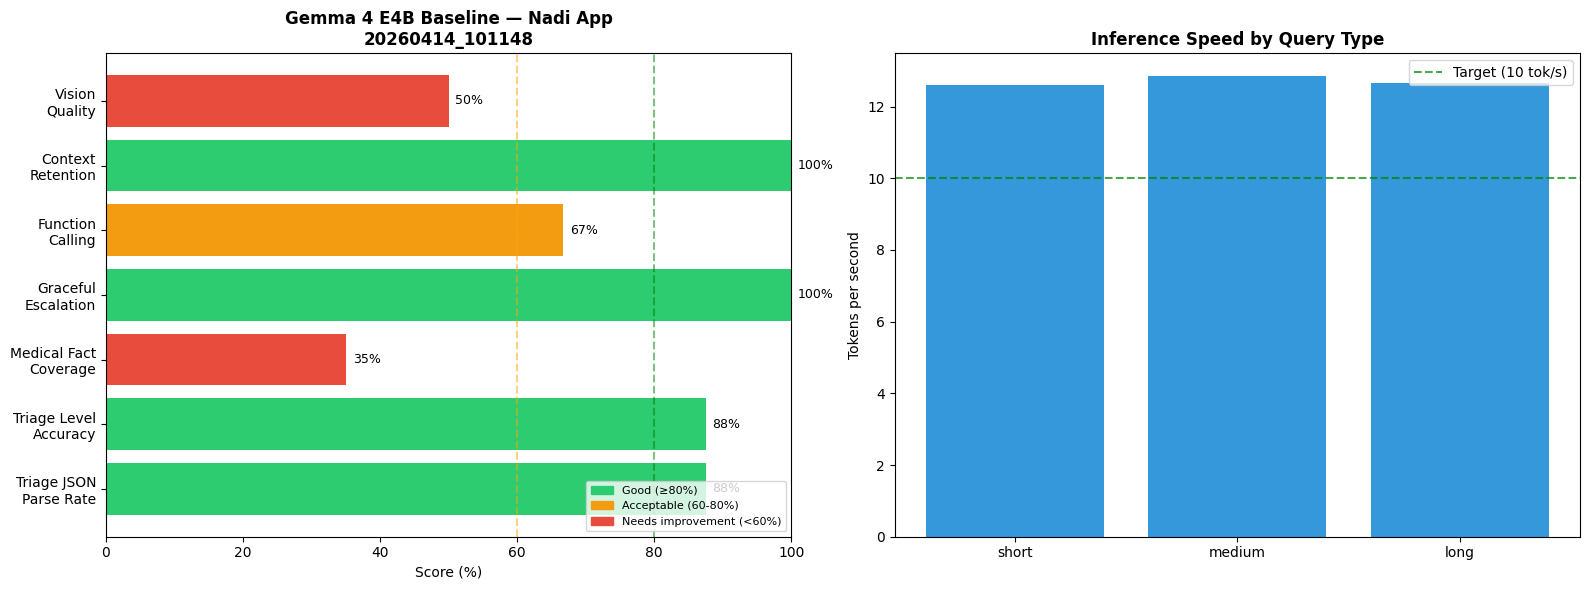


📈 Chart saved: nadi_baseline_20260414_101148.png
📄 Full results saved: baseline_20260414_101148.json
📊 Summary CSV saved: baseline_20260414_101148.csv

✅ BASELINE COMPLETE
Save these files. After finetuning, re-run this notebook
and compare the new scores against this baseline.


In [16]:
# ─── FINAL REPORT ─────────────────────────────────────────────────────────────
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime

print('='*60)
print('NADI — GEMMA 4 E4B BASELINE REPORT')
print('='*60)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# ── Summary Metrics ──
summary = {
    'timestamp': timestamp,
    'model': BASELINE_METRICS['model_id'],
    'quantization': BASELINE_METRICS['quantization'],
    'model_load_time_s': BASELINE_METRICS['model_load_time_seconds'],
    'gpu_memory_gb': BASELINE_METRICS['gpu_memory_used_gb'],
    'avg_tokens_per_second': BASELINE_METRICS.get('avg_tokens_per_second', 0),
    'triage_json_parse_rate': BASELINE_METRICS.get('triage_json_parse_rate', 0),
    'triage_level_accuracy': BASELINE_METRICS.get('triage_level_accuracy', 0),
    'triage_field_completeness': BASELINE_METRICS.get('triage_field_completeness', 0),
    'medical_fact_coverage': BASELINE_METRICS.get('medical_fact_coverage', 0),
    'graceful_escalation_rate': BASELINE_METRICS.get('graceful_escalation_rate', 0),
    'function_calling_accuracy': BASELINE_METRICS.get('function_calling_accuracy', 0),
    'context_retention_rate': BASELINE_METRICS.get('context_retention_rate', 0),
    'vision_response_quality': BASELINE_METRICS.get('vision_response_quality', 0),
}

print('\n📊 BASELINE SUMMARY:')
print(f'  Model load time:          {summary["model_load_time_s"]}s')
print(f'  GPU memory used:          {summary["gpu_memory_gb"]} GB')
print(f'  Avg tokens/second:        {summary["avg_tokens_per_second"]}')
print(f'  Triage JSON parse rate:   {summary["triage_json_parse_rate"]*100:.0f}%')
print(f'  Triage level accuracy:    {summary["triage_level_accuracy"]*100:.0f}%')
print(f'  Field completeness:       {summary["triage_field_completeness"]*100:.0f}%')
print(f'  Medical fact coverage:    {summary["medical_fact_coverage"]*100:.0f}%')
print(f'  Graceful escalation:      {summary["graceful_escalation_rate"]*100:.0f}%')
print(f'  Function calling acc:     {summary["function_calling_accuracy"]*100:.0f}%')
print(f'  Context retention:        {summary["context_retention_rate"]*100:.0f}%')
print(f'  Vision response quality:  {summary["vision_response_quality"]*100:.0f}%')

# ── Radar Chart ──
categories = [
    'Triage JSON\nParse Rate',
    'Triage Level\nAccuracy',
    'Medical Fact\nCoverage',
    'Graceful\nEscalation',
    'Function\nCalling',
    'Context\nRetention',
    'Vision\nQuality',
]
values = [
    summary['triage_json_parse_rate'],
    summary['triage_level_accuracy'],
    summary['medical_fact_coverage'],
    summary['graceful_escalation_rate'],
    summary['function_calling_accuracy'],
    summary['context_retention_rate'],
    summary['vision_response_quality'],
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.6 else '#e74c3c' for v in values]
axes[0].barh(categories, [v*100 for v in values], color=colors)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Score (%)')
axes[0].set_title(f'Gemma 4 E4B Baseline — Nadi App\n{timestamp}', fontweight='bold')
axes[0].axvline(x=80, color='green', linestyle='--', alpha=0.5, label='Target (80%)')
axes[0].axvline(x=60, color='orange', linestyle='--', alpha=0.5, label='Acceptable (60%)')
for i, (cat, val) in enumerate(zip(categories, values)):
    axes[0].text(val*100 + 1, i, f'{val*100:.0f}%', va='center', fontsize=9)
green_patch = mpatches.Patch(color='#2ecc71', label='Good (≥80%)')
orange_patch = mpatches.Patch(color='#f39c12', label='Acceptable (60-80%)')
red_patch = mpatches.Patch(color='#e74c3c', label='Needs improvement (<60%)')
axes[0].legend(handles=[green_patch, orange_patch, red_patch], loc='lower right', fontsize=8)

# Inference speed chart
speed_data = [r for r in BASELINE_METRICS['test_results'] if 'speed' in r['test_id']]
if speed_data:
    labels = [r['test_id'].replace('speed_', '') for r in speed_data]
    times = [r['inference_time_seconds'] for r in speed_data]
    tps = [r['tokens_per_second'] for r in speed_data]
    axes[1].bar(labels, tps, color='#3498db')
    axes[1].set_ylabel('Tokens per second')
    axes[1].set_title('Inference Speed by Query Type', fontweight='bold')
    axes[1].axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Target (10 tok/s)')
    axes[1].legend()

plt.tight_layout()
plt.savefig(f'baseline_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📈 Chart saved: nadi_baseline_{timestamp}.png')

# ── Export full results ──
# JSON (full detail)
full_results = {
    'summary': summary,
    'all_test_results': BASELINE_METRICS['test_results'],
    'triage_detail': triage_results,
    'medical_detail': medical_results,
    'graceful_detail': graceful_results,
    'function_detail': function_results,
    'context_detail': context_results,
    'multilingual_detail': multilingual_scores,
    'vision_detail': vision_results,
}

json_path = f'baseline_{timestamp}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(full_results, f, indent=2, ensure_ascii=False)
print(f'📄 Full results saved: {json_path}')

# CSV (summary)
df_summary = pd.DataFrame([summary])
csv_path = f'baseline_{timestamp}.csv'
df_summary.to_csv(csv_path, index=False)
print(f'📊 Summary CSV saved: {csv_path}')

print('\n✅ BASELINE COMPLETE')
print('Save these files. After finetuning, re-run this notebook')
print('and compare the new scores against this baseline.')

---
## CELL 14 — Download Results
Downloads all output files to your local machine.

In [17]:
# ─── SAVE TO KAGGLE OUTPUT ────────────────────────────────────────────────────
import glob
import shutil
import os

# Kaggle output directory — everything here is downloadable
KAGGLE_OUTPUT = "/kaggle/working/"

files_saved = glob.glob("baseline_*")

if files_saved:
    print("Files ready for download:")
    for f in files_saved:
        # Files are already in /kaggle/working/ so just confirm they exist
        full_path = os.path.join(KAGGLE_OUTPUT, f)
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size_kb:.1f} KB)")

Files ready for download:
  ✅ baseline_20260414_101148.json (70.8 KB)
  ✅ baseline_20260414_101148.png (111.4 KB)
  ✅ baseline_20260414_101148.csv (0.4 KB)
